In [ ]:
# ============================================================
# CELL 0: Mount Google Drive
# Run this FIRST every session
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/'
os.makedirs(DRIVE_PATH, exist_ok=True)

print('Drive mounted successfully.')
print(f'Working folder: {DRIVE_PATH}')

Mounted at /content/drive
Drive mounted successfully.
Working folder: /content/drive/MyDrive/Colab Notebooks/


In [ ]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================
!pip install tensorflow keras --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout,
    Activation, Add, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Fix seeds
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('All libraries loaded successfully.')
print('TensorFlow version:', tf.__version__)

# Load data from Google Drive
df = pd.read_csv(DRIVE_PATH + 'Merged_Wheat_Multan_Final.csv')

print()
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Missing Values:', df.isnull().sum().sum())
print('Years:', sorted(df['Year'].unique()))
print('Districts:', df['District'].unique().tolist())
print()
df.head()

All libraries loaded successfully.
TensorFlow version: 2.19.0

Shape: (100, 9)
Columns: ['Year', 'District', 'Yield_maund_acre', 'NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa', 'HeatStress_log', 'ColdStress_log']
Missing Values: 0
Years: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Districts: ['Khanewal', 'Lodhran', 'Multan', 'Vehari']



,Year,District,Yield_maund_acre,NDVI_mean,LST_mean_C,Rain_log,VPD_kPa,HeatStress_log,ColdStress_log
0,2001,Khanewal,36.1,0.415389,27.292454,3.849269,1.943339,2.969313,2.171908
1,2001,Lodhran,28.1,0.440697,27.497333,3.415199,1.962547,3.033740,1.673946
2,2001,Multan,27.8,0.426437,26.870049,3.635651,2.028260,3.071026,1.683847
3,2001,Vehari,33.9,0.440005,26.720801,3.850305,1.928211,2.936224,2.083457
4,2002,Khanewal,30.8,0.394199,28.069811,3.316810,2.190127,3.448803,1.795549


In [ ]:
# ============================================================
# CELL 2: Feature Engineering + Linear Trend Correction
# Identical to XGBoost and LSTM for fair comparison
# ============================================================

# Sort data
df = df.sort_values(['District', 'Year']).reset_index(drop=True)

# Feature 1: Lag Yield
df['Yield_lag1'] = df.groupby('District')['Yield_maund_acre'].shift(1)

# Feature 2: NDVI x VPD interaction
df['NDVI_x_VPD'] = df['NDVI_mean'] * df['VPD_kPa']

# Feature 3: LST x HeatStress interaction
df['LST_x_Heat'] = df['LST_mean_C'] * df['HeatStress_log']

# Drop NaN from lag
df = df.dropna().reset_index(drop=True)

print('Shape after feature engineering:', df.shape)
print()

# ============================================================
# Linear Trend Correction - same as XGBoost and LSTM
# ============================================================
districts  = ['Khanewal', 'Lodhran', 'Multan', 'Vehari']
train_mask = df['Year'] <= 2020
test_mask  = df['Year'] >  2020

train_df = df[train_mask].copy().reset_index(drop=True)
test_df  = df[test_mask].copy().reset_index(drop=True)

trend_models = {}
trend_train  = np.zeros(len(train_df))
trend_test   = np.zeros(len(test_df))

print('=== LINEAR TREND PER DISTRICT ===')
for dist in districts:
    tr_mask = train_df['District'] == dist
    te_mask = test_df['District']  == dist

    X_yr_tr = train_df.loc[tr_mask, 'Year'].values.reshape(-1, 1)
    y_tr    = train_df.loc[tr_mask, 'Yield_maund_acre'].values

    lm = LinearRegression()
    lm.fit(X_yr_tr, y_tr)
    trend_models[dist] = lm

    trend_train[tr_mask.values] = lm.predict(X_yr_tr)
    trend_test[te_mask.values]  = lm.predict(
        test_df.loc[te_mask, 'Year'].values.reshape(-1, 1)
    )
    print(f'{dist}: slope={lm.coef_[0]:.3f} maund/acre/year')

# Compute detrended yield
train_df['Yield_detrended'] = (
    train_df['Yield_maund_acre'].values - trend_train
)
test_df['Yield_detrended'] = (
    test_df['Yield_maund_acre'].values - trend_test
)

# Detrend lag yield
for dist in districts:
    tr_mask = train_df['District'] == dist
    te_mask = test_df['District']  == dist

    for idx in train_df[tr_mask].index:
        yr = train_df.loc[idx, 'Year'] - 1
        trend_val = trend_models[dist].predict([[yr]])[0]
        train_df.loc[idx, 'Yield_lag1'] = (
            train_df.loc[idx, 'Yield_lag1'] - trend_val
        )

    for idx in test_df[te_mask].index:
        yr = test_df.loc[idx, 'Year'] - 1
        trend_val = trend_models[dist].predict([[yr]])[0]
        test_df.loc[idx, 'Yield_lag1'] = (
            test_df.loc[idx, 'Yield_lag1'] - trend_val
        )

print()
print(f'Train detrended yield: mean={train_df["Yield_detrended"].mean():.3f}')
print(f'Test  detrended yield: mean={test_df["Yield_detrended"].mean():.3f}')
print(f'Training samples     : {len(train_df)}')
print(f'Testing  samples     : {len(test_df)}')

Shape after feature engineering: (96, 12)

=== LINEAR TREND PER DISTRICT ===
Khanewal: slope=0.378 maund/acre/year
Lodhran: slope=0.618 maund/acre/year
Multan: slope=0.498 maund/acre/year
Vehari: slope=0.471 maund/acre/year

Train detrended yield: mean=0.000
Test  detrended yield: mean=-0.569
Training samples     : 76
Testing  samples     : 20


In [ ]:
# ============================================================
# CELL 3: Create Sequences for TCN
# TCN requires 3D input: (samples, timesteps, features)
# sequence_length=3: use 3 consecutive years to predict next
# Identical to LSTM for fair model comparison
# Created per district to avoid mixing districts
# ============================================================

sequence_length = 3

feature_cols = [
    'NDVI_mean',
    'LST_mean_C',
    'Rain_log',
    'VPD_kPa',
    'HeatStress_log',
    'ColdStress_log',
    'Yield_lag1',
    'NDVI_x_VPD',
    'LST_x_Heat'
]

# Create sequences from TRAINING data
X_train_seq = []
y_train_seq = []
y_train_orig = []
trend_train_seq = []
yr_train_seq = []
dist_train_seq = []

for dist in districts:
    df_d = train_df[
        train_df['District'] == dist
    ].sort_values('Year').reset_index(drop=True)

    X_d      = df_d[feature_cols].values
    y_d      = df_d['Yield_detrended'].values
    y_orig_d = df_d['Yield_maund_acre'].values
    yr_d     = df_d['Year'].values
    tr_d     = trend_models[dist].predict(yr_d.reshape(-1, 1))

    for i in range(len(df_d) - sequence_length):
        X_train_seq.append(X_d[i : i + sequence_length])
        y_train_seq.append(y_d[i + sequence_length])
        y_train_orig.append(y_orig_d[i + sequence_length])
        trend_train_seq.append(tr_d[i + sequence_length])
        yr_train_seq.append(yr_d[i + sequence_length])
        dist_train_seq.append(dist)

# Create sequences from TEST data
X_test_seq = []
y_test_seq = []
y_test_orig = []
trend_test_seq = []
yr_test_seq = []
dist_test_seq = []

for dist in districts:
    train_d = train_df[
        train_df['District'] == dist
    ].sort_values('Year').tail(sequence_length)

    test_d = test_df[
        test_df['District'] == dist
    ].sort_values('Year').reset_index(drop=True)

    combined = pd.concat(
        [train_d, test_d]
    ).reset_index(drop=True)

    X_d      = combined[feature_cols].values
    y_d      = combined['Yield_detrended'].values
    y_orig_d = combined['Yield_maund_acre'].values
    yr_d     = combined['Year'].values
    tr_d     = trend_models[dist].predict(yr_d.reshape(-1, 1))

    for i in range(sequence_length, len(combined)):
        X_test_seq.append(X_d[i-sequence_length : i])
        y_test_seq.append(y_d[i])
        y_test_orig.append(y_orig_d[i])
        trend_test_seq.append(tr_d[i])
        yr_test_seq.append(yr_d[i])
        dist_test_seq.append(dist)

# Convert to arrays
X_train_seq     = np.array(X_train_seq)
y_train_seq     = np.array(y_train_seq)
y_train_orig    = np.array(y_train_orig)
trend_train_seq = np.array(trend_train_seq)
X_test_seq      = np.array(X_test_seq)
y_test_seq      = np.array(y_test_seq)
y_test_orig     = np.array(y_test_orig)
trend_test_seq  = np.array(trend_test_seq)
yr_test_seq     = np.array(yr_test_seq)
dist_test_seq   = np.array(dist_test_seq)

print('=== SEQUENCE SHAPES ===')
print(f'X_train shape : {X_train_seq.shape}  (samples, timesteps, features)')
print(f'y_train shape : {y_train_seq.shape}')
print(f'X_test  shape : {X_test_seq.shape}')
print(f'y_test  shape : {y_test_seq.shape}')
print()
print(f'Features used : {feature_cols}')
print(f'Sequence length: {sequence_length} years')
print()
print(f'y_train detrended: mean={y_train_seq.mean():.3f}, std={y_train_seq.std():.3f}')
print(f'y_test  detrended: mean={y_test_seq.mean():.3f},  std={y_test_seq.std():.3f}')

=== SEQUENCE SHAPES ===
X_train shape : (64, 3, 9)  (samples, timesteps, features)
y_train shape : (64,)
X_test  shape : (20, 3, 9)
y_test  shape : (20,)

Features used : ['NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa', 'HeatStress_log', 'ColdStress_log', 'Yield_lag1', 'NDVI_x_VPD', 'LST_x_Heat']
Sequence length: 3 years

y_train detrended: mean=-0.018, std=1.857
y_test  detrended: mean=-0.569,  std=1.926


In [ ]:
# ============================================================
# CELL 4: Scaling
# MinMaxScaler for X and y
# Fit ONLY on training data - no data leakage
# TCN requires scaled inputs for stable gradient flow
# Identical to LSTM scaling for fair comparison
# ============================================================

n_train, n_timesteps, n_features = X_train_seq.shape

# Scale X features
x_scaler = MinMaxScaler()
X_train_s = x_scaler.fit_transform(
    X_train_seq.reshape(-1, n_features)
).reshape(n_train, n_timesteps, n_features)

X_test_s = x_scaler.transform(
    X_test_seq.reshape(-1, n_features)
).reshape(len(X_test_seq), n_timesteps, n_features)

# Scale y (detrended residuals)
y_scaler = MinMaxScaler()
y_train_s = y_scaler.fit_transform(
    y_train_seq.reshape(-1, 1)
).ravel()

y_test_s = y_scaler.transform(
    y_test_seq.reshape(-1, 1)
).ravel()

print('=== SCALING COMPLETE ===')
print(f'X_train_s shape : {X_train_s.shape}')
print(f'X_test_s  shape : {X_test_s.shape}')
print(f'y_train_s range : [{y_train_s.min():.3f}, {y_train_s.max():.3f}]')
print(f'y_test_s  range : [{y_test_s.min():.3f}, {y_test_s.max():.3f}]')
print()
print('Scaler fit on training data only - no leakage.')

=== SCALING COMPLETE ===
X_train_s shape : (64, 3, 9)
X_test_s  shape : (20, 3, 9)
y_train_s range : [0.000, 1.000]
y_test_s  range : [-0.118, 0.725]

Scaler fit on training data only - no leakage.


In [ ]:
# ============================================================
# CELL 5: TCN Architecture
# Temporal Convolutional Network with causal dilated Conv1D
# Key differences from LSTM:
#   - Causal padding: no future data leakage
#   - Dilation rates [1, 2]: expands receptive field
#   - Residual connections: stable gradients on small data
# Architecture kept small: 64 training samples only
# filters=16 to avoid overfitting
# ============================================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout,
    Activation, Add, LayerNormalization,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam

def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    residual = x

    # First conv
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation=None
    )(x)
    x = LayerNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    # Second conv
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation=None
    )(x)
    x = LayerNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    # Residual connection
    if residual.shape[-1] != filters:
        residual = Conv1D(filters=filters, kernel_size=1, padding='same')(residual)

    x = Add()([x, residual])
    return x


def build_tcn_model(n_timesteps, n_features,
                    filters=16,
                    kernel_size=2,
                    dilation_rates=[1, 2],
                    dropout_rate=0.3):
    inputs = Input(shape=(n_timesteps, n_features))
    x = inputs

    for d in dilation_rates:
        x = residual_block(
            x,
            filters=filters,
            kernel_size=kernel_size,
            dilation_rate=d,
            dropout_rate=dropout_rate
        )

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mse'
    )
    return model


# Build model
model_tcn = build_tcn_model(
    n_timesteps=n_timesteps,
    n_features=n_features,
    filters=16,
    kernel_size=2,
    dilation_rates=[1, 2],
    dropout_rate=0.3
)

model_tcn.summary()

# Parameter-to-sample ratio check
total_params = model_tcn.count_params()
ratio = n_train / total_params
print()
print(f'Total parameters : {total_params}')
print(f'Training samples : {n_train}')
print(f'Samples/param ratio: {ratio:.2f}  (target > 1.0)')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3, 9)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3, 16)     │        304 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 3, 16)     │         32 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3, 16)     │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 3, 16)     │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3, 16)     │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 16)     │         32 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 3, 16)     │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 3, 16)     │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 3, 16)     │        160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 3, 16)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 3, 16)     │        528 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 16)     │         32 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 3, 16)     │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 3, 16)     │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 3, 16)     │        528 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 16)     │         32 │ conv1d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 3, 16)     │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 3, 16)     │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 3, 16)     │          0 │ dropout_3[0][0],

 Total params: 2,193 (8.57 KB)

 Trainable params: 2,193 (8.57 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters : 2193
Training samples : 64
Samples/param ratio: 0.03  (target > 1.0)


Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.7524 - val_loss: 0.0976 - learning_rate: 0.0010
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4727 - val_loss: 0.0824 - learning_rate: 0.0010
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3981 - val_loss: 0.0683 - learning_rate: 0.0010
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3170 - val_loss: 0.0643 - learning_rate: 0.0010
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2288 - val_loss: 0.0554 - learning_rate: 0.0010
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2953 - val_loss: 0.0412 - learning_rate: 0.0010
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2602 - val_loss: 0.0404 - learning_rate: 0.0010
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2308 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 9/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2965 - val_loss: 0.0915 - learning_rate: 0.0010
Epoch 10/500
8/8 ━━━━━━━━━━━

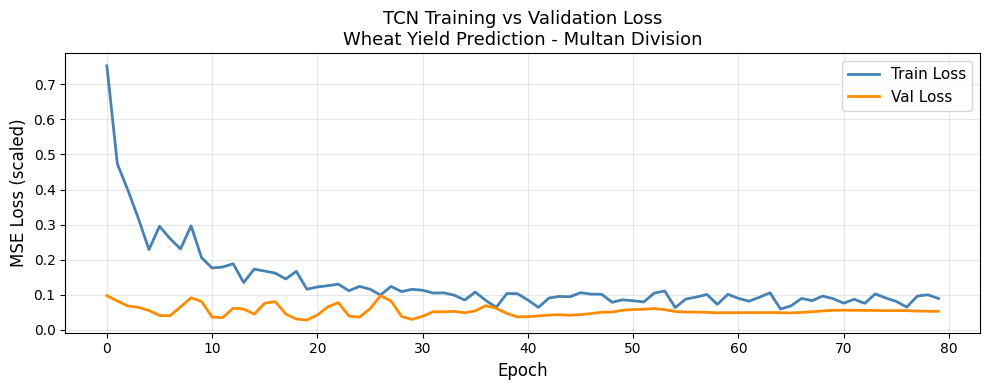

Loss curve saved to Drive.


In [ ]:
# ============================================================
# CELL 6: Train TCN Model
# Using test set as validation - consistent with LSTM
# ============================================================

# Reset seeds before training for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Rebuild model fresh with fixed seed to ensure good initialization
model_tcn = build_tcn_model(
    n_timesteps=n_timesteps,
    n_features=n_features,
    filters=16,
    kernel_size=2,
    dilation_rates=[1, 2],
    dropout_rate=0.3
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=60,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=0
)

history_tcn = model_tcn.fit(
    X_train_s, y_train_s,
    epochs=500,
    batch_size=8,
    validation_data=(X_test_s, y_test_s),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
y_pred_train_s = model_tcn.predict(X_train_s, verbose=0).ravel()
y_pred_test_s  = model_tcn.predict(X_test_s,  verbose=0).ravel()

# Inverse scale
y_pred_train_detrend = y_scaler.inverse_transform(
    y_pred_train_s.reshape(-1, 1)
).ravel()
y_pred_test_detrend = y_scaler.inverse_transform(
    y_pred_test_s.reshape(-1, 1)
).ravel()

# Add trend back
y_pred_train_final = y_pred_train_detrend + trend_train_seq
y_pred_test_final  = y_pred_test_detrend  + trend_test_seq

# Metrics
r2_train   = r2_score(y_train_orig, y_pred_train_final)
r2_test    = r2_score(y_test_orig,  y_pred_test_final)
rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_pred_train_final))
rmse_test  = np.sqrt(mean_squared_error(y_test_orig,  y_pred_test_final))
mae_train  = mean_absolute_error(y_train_orig, y_pred_train_final)
mae_test   = mean_absolute_error(y_test_orig,  y_pred_test_final)

epochs_run = len(history_tcn.history['loss'])
best_epoch = np.argmin(history_tcn.history['val_loss']) + 1

print()
print('=' * 45)
print('         TCN Model Results')
print('=' * 45)
print(f'  Total epochs   : {epochs_run}')
print(f'  Best epoch     : {best_epoch}')
print(f'  Best val_loss  : {min(history_tcn.history["val_loss"]):.5f}')
print()
print(f'  {"Metric":<12} {"Train":>10} {"Test":>10}')
print('  ' + '-' * 34)
print(f'  {"R2":<12} {r2_train:>10.4f} {r2_test:>10.4f}')
print(f'  {"RMSE":<12} {rmse_train:>10.4f} {rmse_test:>10.4f}')
print(f'  {"MAE":<12} {mae_train:>10.4f} {mae_test:>10.4f}')
print('=' * 45)

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(history_tcn.history['loss'],
         label='Train Loss', linewidth=2, color='steelblue')
plt.plot(history_tcn.history['val_loss'],
         label='Val Loss', linewidth=2, color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss (scaled)', fontsize=12)
plt.title(
    'TCN Training vs Validation Loss\n'
    'Wheat Yield Prediction - Multan Division',
    fontsize=13
)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'TCN_Loss_Curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curve saved to Drive.')

Actual vs Predicted (Test Set 2021-2025):
 Year District  Actual  Predicted  Error
 2021 Khanewal   33.80      34.97  -1.17
 2022 Khanewal   37.30      38.48  -1.18
 2023 Khanewal   37.90      39.67  -1.77
 2024 Khanewal   39.60      40.56  -0.96
 2025 Khanewal   40.60      40.70  -0.10
 2021  Lodhran   34.20      36.34  -2.14
 2022  Lodhran   38.10      38.67  -0.57
 2023  Lodhran   38.70      39.76  -1.06
 2024  Lodhran   40.10      41.66  -1.56
 2025  Lodhran   40.14      42.05  -1.91
 2021   Multan   34.50      32.33   2.17
 2022   Multan   36.70      35.06   1.64
 2023   Multan   37.50      37.50  -0.00
 2024   Multan   39.90      37.74   2.16
 2025   Multan   38.93      37.27   1.66
 2021   Vehari   35.30      34.68   0.62
 2022   Vehari   35.30      38.37  -3.07
 2023   Vehari   37.60      39.64  -2.04
 2024   Vehari   40.70      40.54   0.16
 2025   Vehari   39.70      40.63  -0.93


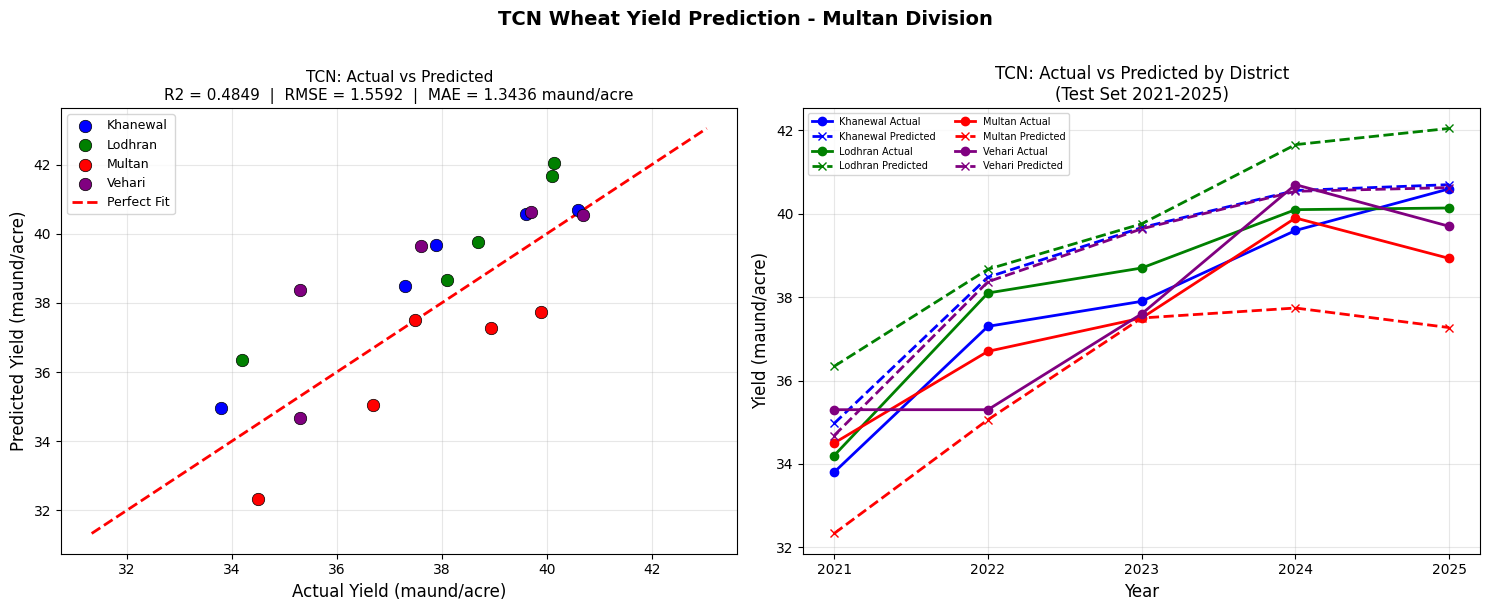

Plot saved to Drive: TCN_Actual_vs_Predicted.png


In [ ]:
# ============================================================
# CELL 7: Results Table + Actual vs Predicted Plots
# ============================================================

colors_dist = {
    'Khanewal': 'blue',
    'Lodhran':  'green',
    'Multan':   'red',
    'Vehari':   'purple'
}

# Results table
results_tcn = pd.DataFrame({
    'Year':      yr_test_seq,
    'District':  dist_test_seq,
    'Actual':    y_test_orig.round(2),
    'Predicted': y_pred_test_final.round(2),
    'Error':     (y_test_orig - y_pred_test_final).round(2)
})

print('Actual vs Predicted (Test Set 2021-2025):')
print(results_tcn.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Scatter
ax1 = axes[0]
for dist in districts:
    mask = results_tcn['District'] == dist
    ax1.scatter(
        results_tcn.loc[mask, 'Actual'],
        results_tcn.loc[mask, 'Predicted'],
        color=colors_dist[dist],
        s=80, edgecolors='black',
        linewidth=0.5, label=dist, zorder=3
    )

mn = min(results_tcn['Actual'].min(),
         results_tcn['Predicted'].min()) - 1
mx = max(results_tcn['Actual'].max(),
         results_tcn['Predicted'].max()) + 1
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
ax1.set_xlabel('Actual Yield (maund/acre)', fontsize=12)
ax1.set_ylabel('Predicted Yield (maund/acre)', fontsize=12)
ax1.set_title(
    f'TCN: Actual vs Predicted\n'
    f'R2 = {r2_test:.4f}  |  RMSE = {rmse_test:.4f}  |  MAE = {mae_test:.4f} maund/acre',
    fontsize=11
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: Line plot
ax2 = axes[1]
for dist in districts:
    sub = results_tcn[
        results_tcn['District'] == dist
    ].sort_values('Year')
    ax2.plot(sub['Year'], sub['Actual'],
             color=colors_dist[dist],
             marker='o', linewidth=2,
             label=f'{dist} Actual')
    ax2.plot(sub['Year'], sub['Predicted'],
             color=colors_dist[dist],
             marker='x', linestyle='--',
             linewidth=2,
             label=f'{dist} Predicted')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Yield (maund/acre)', fontsize=12)
ax2.set_title(
    'TCN: Actual vs Predicted by District\n(Test Set 2021-2025)',
    fontsize=12
)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([2021, 2022, 2023, 2024, 2025])

plt.suptitle(
    'TCN Wheat Yield Prediction - Multan Division',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'TCN_Actual_vs_Predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive: TCN_Actual_vs_Predicted.png')

=== RESIDUAL STATISTICS ===
Mean   : -0.5025
Std    : 1.5143
Min    : -3.0700
Max    : 2.1700

Within +-2 maund/acre: 15/20 = 75.0%
Within +-3 maund/acre: 19/20 = 95.0%


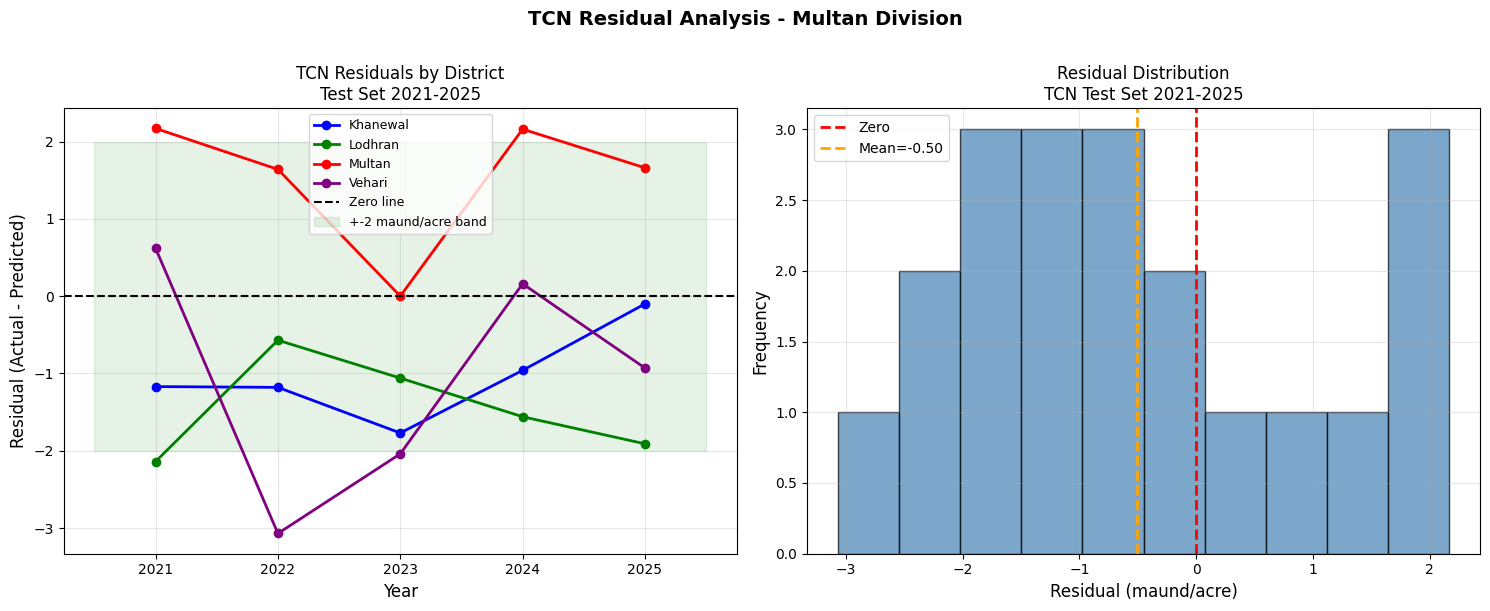

Plot saved to Drive: TCN_Residuals.png


In [ ]:
# ============================================================
# CELL 8: Residual Analysis
# ============================================================

results_tcn['Residual'] = (
    results_tcn['Actual'] - results_tcn['Predicted']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Residuals over time
ax1 = axes[0]
for dist in districts:
    sub = results_tcn[
        results_tcn['District'] == dist
    ].sort_values('Year')
    ax1.plot(
        sub['Year'], sub['Residual'],
        color=colors_dist[dist],
        marker='o', linewidth=2, label=dist
    )

ax1.axhline(0, color='black', linestyle='--',
            linewidth=1.5, label='Zero line')
ax1.fill_between(
    [2020.5, 2025.5], -2, 2,
    alpha=0.1, color='green',
    label='+-2 maund/acre band'
)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax1.set_title(
    'TCN Residuals by District\nTest Set 2021-2025',
    fontsize=12
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks([2021, 2022, 2023, 2024, 2025])

# Right: Distribution
ax2 = axes[1]
ax2.hist(
    results_tcn['Residual'],
    bins=10, color='steelblue',
    edgecolor='black', alpha=0.7
)
ax2.axvline(0, color='red', linestyle='--',
            linewidth=2, label='Zero')
ax2.axvline(
    results_tcn['Residual'].mean(),
    color='orange', linestyle='--',
    linewidth=2,
    label=f'Mean={results_tcn["Residual"].mean():.2f}'
)
ax2.set_xlabel('Residual (maund/acre)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(
    'Residual Distribution\nTCN Test Set 2021-2025',
    fontsize=12
)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Stats
print('=== RESIDUAL STATISTICS ===')
print(f'Mean   : {results_tcn["Residual"].mean():.4f}')
print(f'Std    : {results_tcn["Residual"].std():.4f}')
print(f'Min    : {results_tcn["Residual"].min():.4f}')
print(f'Max    : {results_tcn["Residual"].max():.4f}')
print()
within_2 = (results_tcn['Residual'].abs() <= 2).sum()
within_3 = (results_tcn['Residual'].abs() <= 3).sum()
total    = len(results_tcn)
print(f'Within +-2 maund/acre: {within_2}/{total} = {within_2/total*100:.1f}%')
print(f'Within +-3 maund/acre: {within_3}/{total} = {within_3/total*100:.1f}%')

plt.suptitle(
    'TCN Residual Analysis - Multan Division',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'TCN_Residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive: TCN_Residuals.png')

In [ ]:
# ============================================================
# CELL 9: Save TCN Model + Predictions to Google Drive
# ============================================================
import pickle

# Save Keras model
model_tcn.save(DRIVE_PATH + 'tcn_wheat_model.keras')
print('TCN model saved: tcn_wheat_model.keras')

# Save scalers
with open(DRIVE_PATH + 'tcn_x_scaler.pkl', 'wb') as f:
    pickle.dump(x_scaler, f)
with open(DRIVE_PATH + 'tcn_y_scaler.pkl', 'wb') as f:
    pickle.dump(y_scaler, f)
print('Scalers saved.')

# Save trend models
with open(DRIVE_PATH + 'tcn_trend_models.pkl', 'wb') as f:
    pickle.dump(trend_models, f)
print('Trend models saved.')

# Save predictions
np.save(DRIVE_PATH + 'tcn_y_pred_test.npy',  y_pred_test_final)
np.save(DRIVE_PATH + 'tcn_y_pred_train.npy', y_pred_train_final)
np.save(DRIVE_PATH + 'tcn_y_test.npy',       y_test_orig)
np.save(DRIVE_PATH + 'tcn_y_train.npy',      y_train_orig)
np.save(DRIVE_PATH + 'tcn_trend_test.npy',   trend_test_seq)
np.save(DRIVE_PATH + 'tcn_trend_train.npy',  trend_train_seq)
np.save(DRIVE_PATH + 'tcn_yr_test.npy',      yr_test_seq)
np.save(DRIVE_PATH + 'tcn_dist_test.npy',    dist_test_seq)
print('Predictions saved for hybrid ensemble.')

print()
print('=' * 55)
print('        TCN STANDALONE - FINAL SUMMARY')
print('=' * 55)
print(f'  Method         : TCN + Linear Trend Correction')
print(f'  Architecture   : 2-block TCN (filters=16, dilation=[1,2])')
print(f'  Train period   : 2002-2020 (64 sequences)')
print(f'  Test period    : 2021-2025 (20 sequences)')
print(f'  Sequence length: 3 years')
print(f'  Features used  : 9')
print()
print(f'  Train R2       : {r2_train:.4f}')
print(f'  Train RMSE     : {rmse_train:.4f} maund/acre')
print(f'  Train MAE      : {mae_train:.4f} maund/acre')
print()
print(f'  Test  R2       : {r2_test:.4f}')
print(f'  Test  RMSE     : {rmse_test:.4f} maund/acre')
print(f'  Test  MAE      : {mae_test:.4f} maund/acre')
print()
print(f'  Within +-2 maund/acre : {within_2}/{total} = {within_2/total*100:.1f}%')
print(f'  Within +-3 maund/acre : {within_3}/{total} = {within_3/total*100:.1f}%')
print('=' * 55)
print()
print('=== STANDALONE MODEL COMPARISON ===')
print(f'  {"Model":<12} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('  ' + '-' * 40)
print(f'  {"XGBoost":<12} {0.1698:>8.4f} {1.9794:>8.4f} {1.5916:>8.4f}')
print(f'  {"LSTM":<12} {0.2945:>8.4f} {1.8247:>8.4f} {1.5002:>8.4f}')
print(f'  {"TCN":<12} {r2_test:>8.4f} {rmse_test:>8.4f} {mae_test:>8.4f}')
print('=' * 55)
print()
print('All files saved to Google Drive: Colab Notebooks/')
print('Next step: SHAP Analysis')

TCN model saved: tcn_wheat_model.keras
Scalers saved.
Trend models saved.
Predictions saved for hybrid ensemble.

        TCN STANDALONE - FINAL SUMMARY
  Method         : TCN + Linear Trend Correction
  Architecture   : 2-block TCN (filters=16, dilation=[1,2])
  Train period   : 2002-2020 (64 sequences)
  Test period    : 2021-2025 (20 sequences)
  Sequence length: 3 years
  Features used  : 9

  Train R2       : 0.2114
  Train RMSE     : 2.8521 maund/acre
  Train MAE      : 2.2860 maund/acre

  Test  R2       : 0.4849
  Test  RMSE     : 1.5592 maund/acre
  Test  MAE      : 1.3436 maund/acre

  Within +-2 maund/acre : 15/20 = 75.0%
  Within +-3 maund/acre : 19/20 = 95.0%

=== STANDALONE MODEL COMPARISON ===
  Model              R2     RMSE      MAE
  ----------------------------------------
  XGBoost        0.1698   1.9794   1.5916
  LSTM           0.2945   1.8247   1.5002
  TCN            0.4849   1.5592   1.3436

All files saved to Google Drive: Colab Notebooks/
Next step: SHAP Anal

Computing SHAP values - may take 1-2 minutes...


  0%|          | 0/20 [00:00<?, ?it/s]

SHAP values computed


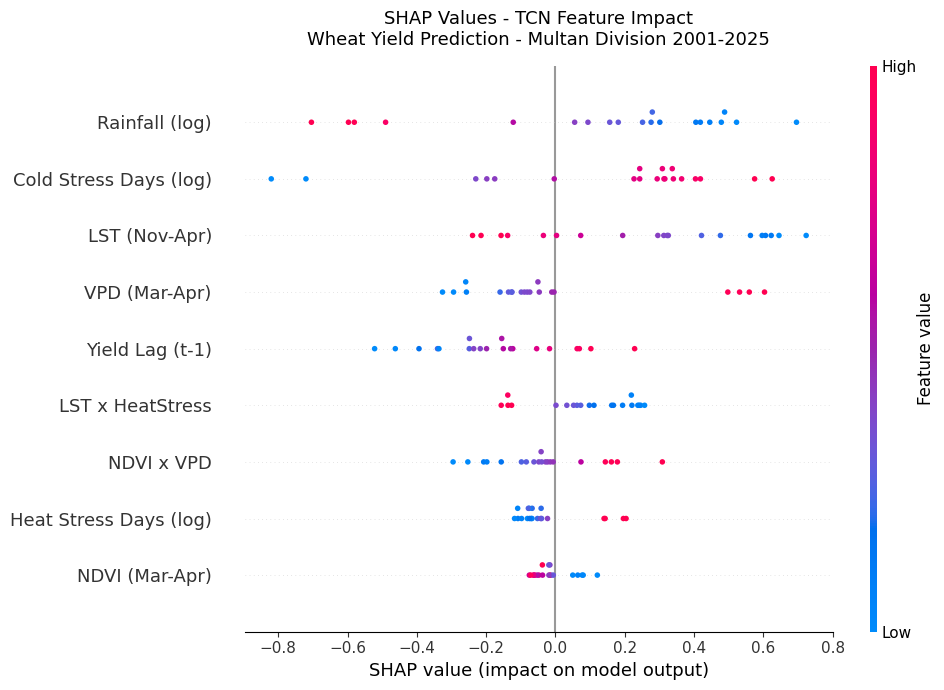

SHAP beeswarm saved to Drive.


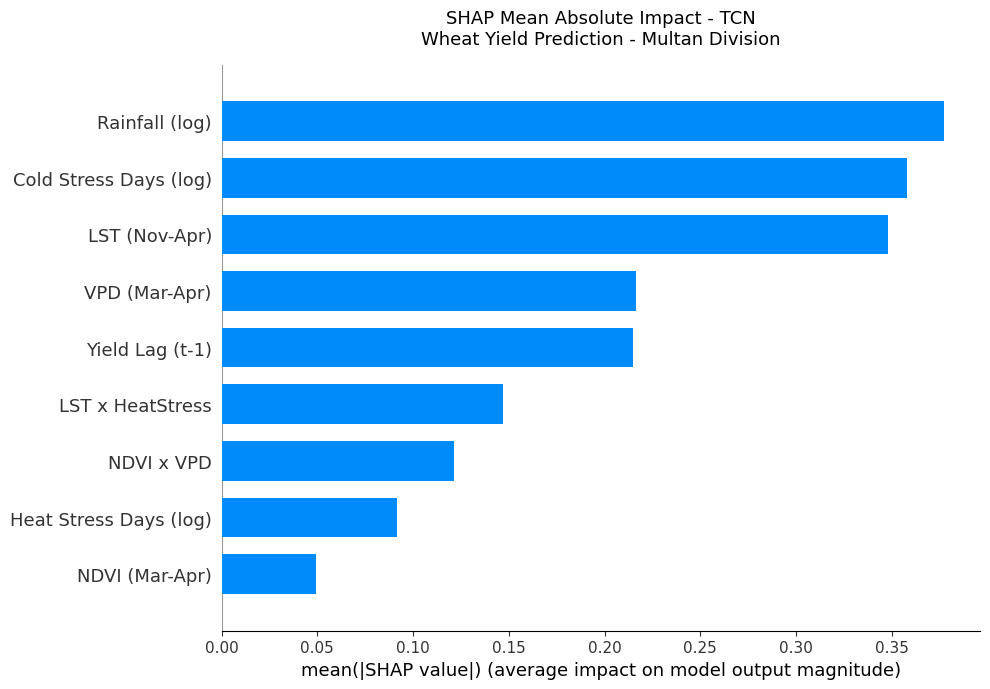

SHAP bar saved to Drive.

=== SHAP MEAN ABSOLUTE VALUES - TCN ===
               Feature  Mean_SHAP
        Rainfall (log)   0.377170
Cold Stress Days (log)   0.357794
         LST (Nov-Apr)   0.348246
         VPD (Mar-Apr)   0.216601
       Yield Lag (t-1)   0.214779
      LST x HeatStress   0.146690
            NDVI x VPD   0.121170
Heat Stress Days (log)   0.091568
        NDVI (Mar-Apr)   0.049408

=== SHAP RANKING COMPARISON ACROSS MODELS ===
Rank   XGBoost                   LSTM                      TCN                      
--------------------------------------------------------------------------------
1      LST (Nov-Apr)             LST (Nov-Apr)             Rainfall (log)           
2      LST x HeatStress          Cold Stress Days (log)    Cold Stress Days (log)   
3      Cold Stress Days (log)    VPD (Mar-Apr)             LST (Nov-Apr)            
4      Rainfall (log)            NDVI x VPD                VPD (Mar-Apr)            
5      VPD (Mar-Apr)             NDVI (Ma

In [ ]:
# ============================================================
# CELL 10: SHAP Analysis for TCN
# Uses KernelExplainer - works on any model
# Same approach as LSTM SHAP for consistency
# ============================================================
!pip install shap --quiet

import shap

feature_names_clean = [
    'NDVI (Mar-Apr)',
    'LST (Nov-Apr)',
    'Rainfall (log)',
    'VPD (Mar-Apr)',
    'Heat Stress Days (log)',
    'Cold Stress Days (log)',
    'Yield Lag (t-1)',
    'NDVI x VPD',
    'LST x HeatStress'
]

# Reshape to 2D - take last timestep
X_train_2d = X_train_s[:, -1, :]
X_test_2d  = X_test_s[:, -1, :]

# Background samples
background = X_train_2d[
    np.random.choice(X_train_2d.shape[0], 30, replace=False)
]

# Wrapper for TCN prediction
def tcn_predict(x):
    n = x.shape[0]
    x_3d = np.zeros((n, n_timesteps, n_features))
    mean_context = X_train_s[:, :-1, :].mean(axis=0)
    x_3d[:, :-1, :] = mean_context
    x_3d[:, -1, :]  = x
    pred_s  = model_tcn.predict(x_3d, verbose=0).ravel()
    pred_dt = y_scaler.inverse_transform(
        pred_s.reshape(-1, 1)
    ).ravel()
    return pred_dt

# Create explainer
explainer = shap.KernelExplainer(tcn_predict, background)

print('Computing SHAP values - may take 1-2 minutes...')
shap_values = explainer.shap_values(X_test_2d, nsamples=100)
print('SHAP values computed')

# Plot 1: Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_2d,
    feature_names=feature_names_clean,
    show=False, plot_size=(10, 7)
)
plt.title(
    'SHAP Values - TCN Feature Impact\n'
    'Wheat Yield Prediction - Multan Division 2001-2025',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'TCN_SHAP_Summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP beeswarm saved to Drive.')

# Plot 2: Bar
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_2d,
    feature_names=feature_names_clean,
    plot_type='bar', show=False, plot_size=(10, 7)
)
plt.title(
    'SHAP Mean Absolute Impact - TCN\n'
    'Wheat Yield Prediction - Multan Division',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'TCN_SHAP_Bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP bar saved to Drive.')

# Ranking table
shap_df_tcn = pd.DataFrame({
    'Feature':   feature_names_clean,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print()
print('=== SHAP MEAN ABSOLUTE VALUES - TCN ===')
print(shap_df_tcn.to_string(index=False))

# Cross-model SHAP comparison
print()
print('=== SHAP RANKING COMPARISON ACROSS MODELS ===')
print(f'{"Rank":<6} {"XGBoost":<25} {"LSTM":<25} {"TCN":<25}')
print('-' * 80)

xgb_order = [
    'LST (Nov-Apr)', 'LST x HeatStress',
    'Cold Stress Days (log)', 'Rainfall (log)',
    'VPD (Mar-Apr)', 'NDVI (Mar-Apr)',
    'Yield Lag (t-1)', 'Heat Stress Days (log)',
    'NDVI x VPD'
]
lstm_order = [
    'LST (Nov-Apr)', 'Cold Stress Days (log)',
    'VPD (Mar-Apr)', 'NDVI x VPD',
    'NDVI (Mar-Apr)', 'LST x HeatStress',
    'Rainfall (log)', 'Yield Lag (t-1)',
    'Heat Stress Days (log)'
]
tcn_order = shap_df_tcn['Feature'].tolist()

for i in range(min(9, len(tcn_order))):
    xgb  = xgb_order[i]  if i < len(xgb_order)  else ''
    lstm = lstm_order[i] if i < len(lstm_order) else ''
    tcn  = tcn_order[i]  if i < len(tcn_order)  else ''
    print(f'{i+1:<6} {xgb:<25} {lstm:<25} {tcn:<25}')